In [3]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model("../models/mobilenet_model.keras")

print(mobilenet_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

None


In [4]:
for i, layer in enumerate(mobilenet_model.layers):
    print(i, layer.name)

0 rescaling
1 mobilenetv2_1.00_224
2 global_average_pooling2d
3 dropout
4 dense


In [5]:
base_model = mobilenet_model.layers[1]

for layer in base_model.layers[-20:]:
    print(layer.name)

block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


In [6]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model("../models/mobilenet_model.keras")

In [85]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "../data/raw/test_set/test_set/cats/cat.4003.jpg"  # use any image that exists

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [86]:
prediction = mobilenet_model.predict(img_array)

print("Raw Prediction:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raw Prediction: 3.798925e-05
Cat


In [87]:
import tensorflow as tf

last_conv_layer = mobilenet_model.get_layer("mobilenetv2_1.00_224").get_layer("out_relu")

print(last_conv_layer)

<ReLU name=out_relu, built=True>


In [88]:
for i, layer in enumerate(
    mobilenet_model.get_layer("mobilenetv2_1.00_224").layers[-10:]
):
    print(i, layer.name)

0 block_16_expand_BN
1 block_16_expand_relu
2 block_16_depthwise
3 block_16_depthwise_BN
4 block_16_depthwise_relu
5 block_16_project
6 block_16_project_BN
7 Conv_1
8 Conv_1_bn
9 out_relu


In [89]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [90]:
def make_gradcam_heatmap(img_array, model):

    base_model = model.get_layer("mobilenetv2_1.00_224")

    conv_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer("out_relu").output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        x = model.layers[0](img_array)   # rescaling

        conv_outputs, features = conv_model(x)

        tape.watch(conv_outputs)

        x = model.layers[2](features)    # GAP
        x = model.layers[3](x)           # dropout
        predictions = model.layers[4](x) # dense


        if predictions[0][0] < 0.5:
            loss = 1 - predictions[:, 0]
        else:
            loss = predictions[:, 0]


    grads = tape.gradient(
        loss,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [91]:
heatmap = make_gradcam_heatmap(
    img_array,
    mobilenet_model
)

print(heatmap.shape)

(7, 7)


In [92]:
print(mobilenet_model.inputs)
print(mobilenet_model.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_661>]


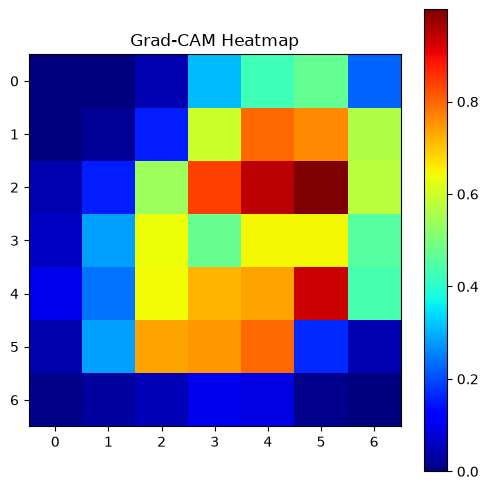

In [93]:
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

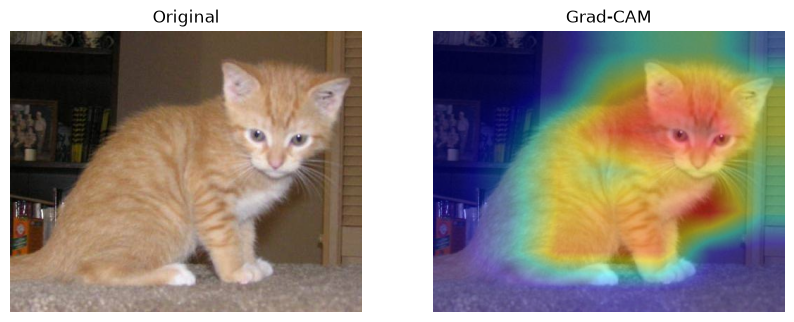

In [96]:
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

heatmap_resized = cv2.resize(
    heatmap,
    (img.shape[1], img.shape[0])
)

heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

superimposed_img = cv2.addWeighted(
    img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [95]:
cv2.imwrite(
    "../results/gradcam_output.jpg",
    cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR)
)

True